# Lending Club Credit Risk Analysis
## Feature Engineering

**Objective:** Transform raw Lending Club columns into model-ready features that 
capture credit risk more precisely than the originals. Every feature created here 
is grounded in a lending business rationale not just statistical convenience.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pyarrow

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})

FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Reload raw data & re-apply target definition from notebook 01 ──────────────
DATA_PATH = "../data/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

known_outcomes = ['Fully Paid', 'Charged Off']
df = df[df['loan_status'].isin(known_outcomes)].copy()
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high']) / 2

print(f"✓ Data loaded: {len(df):,} loans")
print(f"✓ Default rate: {df['default'].mean():.2%}")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ Data loaded: 1,345,310 loans
✓ Default rate: 19.96%


---
## Part 1: Date-Based Features

The date a loan was issued carries macro-level signal. A loan originated in 2008 
faced a collapsing economy. One issued in 2015 faced a stable expansion. We also 
extract how long a borrower has had credit. Older credit histories generally 
indicate more stable borrowers.

In [4]:
# Credit history length at origination (months)
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_age_months'] = (
    (df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12 +
    (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
)
# Cap negatives (data entry errors) at zero
df['credit_age_months'] = df['credit_age_months'].clip(lower=0)

print("credit_age_months — summary:")
print(df['credit_age_months'].describe().round(1).to_string())
print(f"\nDefault rate by credit age quartile:")

df['credit_age_quartile'] = pd.qcut(df['credit_age_months'], q=4,
                                     labels=['Q1 (shortest)', 'Q2', 'Q3', 'Q4 (longest)'])
print(df.groupby('credit_age_quartile', observed=True)['default'].mean()
        .map('{:.2%}'.format).to_string())

credit_age_months — summary:
count    1345310.0
mean         195.1
std           90.1
min           36.0
25%          135.0
50%          177.0
75%          240.0
max          999.0

Default rate by credit age quartile:
credit_age_quartile
Q1 (shortest)    22.09%
Q2               20.56%
Q3               19.13%
Q4 (longest)     18.02%


---
## Part 2: Borrower Capacity Features

These features capture whether a borrower can realistically afford the loan
independent of their credit history. A high income means little if the loan 
is proportionally enormous.

In [5]:
# Loan-to-income ratio: how large is this loan relative to annual income?
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'].replace(0, np.nan)

# Monthly debt burden: instalment as % of implied monthly income
df['monthly_inc'] = df['annual_inc'] / 12
df['instalment_to_income'] = df['installment'] / df['monthly_inc'].replace(0, np.nan)

# Cap extreme outliers (top 1%) — likely data errors
lti_cap = df['loan_to_income'].quantile(0.99)
iti_cap = df['instalment_to_income'].quantile(0.99)
df['loan_to_income'] = df['loan_to_income'].clip(upper=lti_cap)
df['instalment_to_income'] = df['instalment_to_income'].clip(upper=iti_cap)

print("loan_to_income — summary:")
print(df['loan_to_income'].describe().round(4).to_string())
print(f"\ninstalment_to_income — summary:")
print(df['instalment_to_income'].describe().round(4).to_string())

print(f"\nDefault rate by loan_to_income quartile:")
df['lti_quartile'] = pd.qcut(df['loan_to_income'], q=4,
                               labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
print(df.groupby('lti_quartile', observed=True)['default'].mean()
        .map('{:.2%}'.format).to_string())

loan_to_income — summary:
count    1.344949e+06
mean     2.133000e-01
std      1.138000e-01
min      2.000000e-04
25%      1.247000e-01
50%      2.000000e-01
75%      2.909000e-01
max      5.000000e-01

instalment_to_income — summary:
count    1.344949e+06
mean     7.880000e-02
std      4.250000e-02
min      1.000000e-04
25%      4.630000e-02
50%      7.220000e-02
75%      1.054000e-01
max      1.994000e-01

Default rate by loan_to_income quartile:
lti_quartile
Q1 (lowest)     13.69%
Q2              17.05%
Q3              21.25%
Q4 (highest)    28.17%


---
## Part 3: Credit Behaviour Features

These features capture *how* a borrower uses credit, not just whether they 
have it. High revolving utilisation signals someone living close to their 
credit limits. A delinquency flag captures past payment failures directly.

In [6]:
# Revolving utilisation segments
df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')

bins   = [-np.inf, 0.2, 0.5, 0.75, np.inf]
labels = ['Low (0–20%)', 'Medium (20–50%)', 'High (50–75%)', 'Very High (75%+)']
df['revol_util_segment'] = pd.cut(df['revol_util'] / 100, bins=bins, labels=labels)

print("Default rate by revolving utilisation segment:")
print(df.groupby('revol_util_segment', observed=True)['default'].mean()
        .map('{:.2%}'.format).to_string())

# Delinquency flag: any delinquency in past 2 years?
df['delinq_flag'] = (df['delinq_2yrs'] > 0).astype(int)

print(f"\nDefault rate — no delinquency: "
      f"{df[df['delinq_flag']==0]['default'].mean():.2%}")
print(f"Default rate — has delinquency: "
      f"{df[df['delinq_flag']==1]['default'].mean():.2%}")

# Public records flag
df['pub_rec_flag'] = (df['pub_rec'] > 0).astype(int)

print(f"\nDefault rate — no public records: "
      f"{df[df['pub_rec_flag']==0]['default'].mean():.2%}")
print(f"Default rate — has public records: "
      f"{df[df['pub_rec_flag']==1]['default'].mean():.2%}")

Default rate by revolving utilisation segment:
revol_util_segment
Low (0–20%)         14.94%
Medium (20–50%)     18.75%
High (50–75%)       21.42%
Very High (75%+)    22.60%

Default rate — no delinquency: 19.61%
Default rate — has delinquency: 21.45%

Default rate — no public records: 19.39%
Default rate — has public records: 22.75%


---
## Part 4: Loan Structure Features

The structure of the loan itself carries risk signal. A 60-month loan exposes 
the lender to risk for twice as long as a 36-month loan. Interest rate relative 
to the borrower's grade captures whether this specific loan is priced high or 
low within its risk tier.

In [7]:
# Term as numeric (remove " months")
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(int)

print("Default rate by term:")
print(df.groupby('term_months')['default'].mean()
        .map('{:.2%}'.format).to_string())

# Interest rate deviation from grade average
# (is this loan priced high or low within its grade bucket?)
grade_avg_rate = df.groupby('grade', observed=True)['int_rate'].transform('mean')
df['int_rate_grade_dev'] = df['int_rate'] - grade_avg_rate

print(f"\nint_rate_grade_dev — summary:")
print(df['int_rate_grade_dev'].describe().round(4).to_string())

print(f"\nDefault rate by int_rate_grade_dev quartile:")
df['rate_dev_quartile'] = pd.qcut(df['int_rate_grade_dev'], q=4,
                                   labels=['Q1 (below avg)', 'Q2', 'Q3', 'Q4 (above avg)'])
print(df.groupby('rate_dev_quartile', observed=True)['default'].mean()
        .map('{:.2%}'.format).to_string())

Default rate by term:
term_months
36    15.99%
60    32.45%

int_rate_grade_dev — summary:
count    1.345310e+06
mean    -0.000000e+00
std      1.437700e+00
min     -2.172590e+01
25%     -1.031200e+00
50%     -3.120000e-02
75%      8.284000e-01
max      6.131900e+00

Default rate by int_rate_grade_dev quartile:
rate_dev_quartile
Q1 (below avg)    20.02%
Q2                19.46%
Q3                17.70%
Q4 (above avg)    22.63%


---
## Part 5: Visualising the Engineered Features

For each key engineered feature, we validate that it meaningfully separates 
defaulters from non-defaulters. A feature that doesn't separate the classes 
won't help the model.

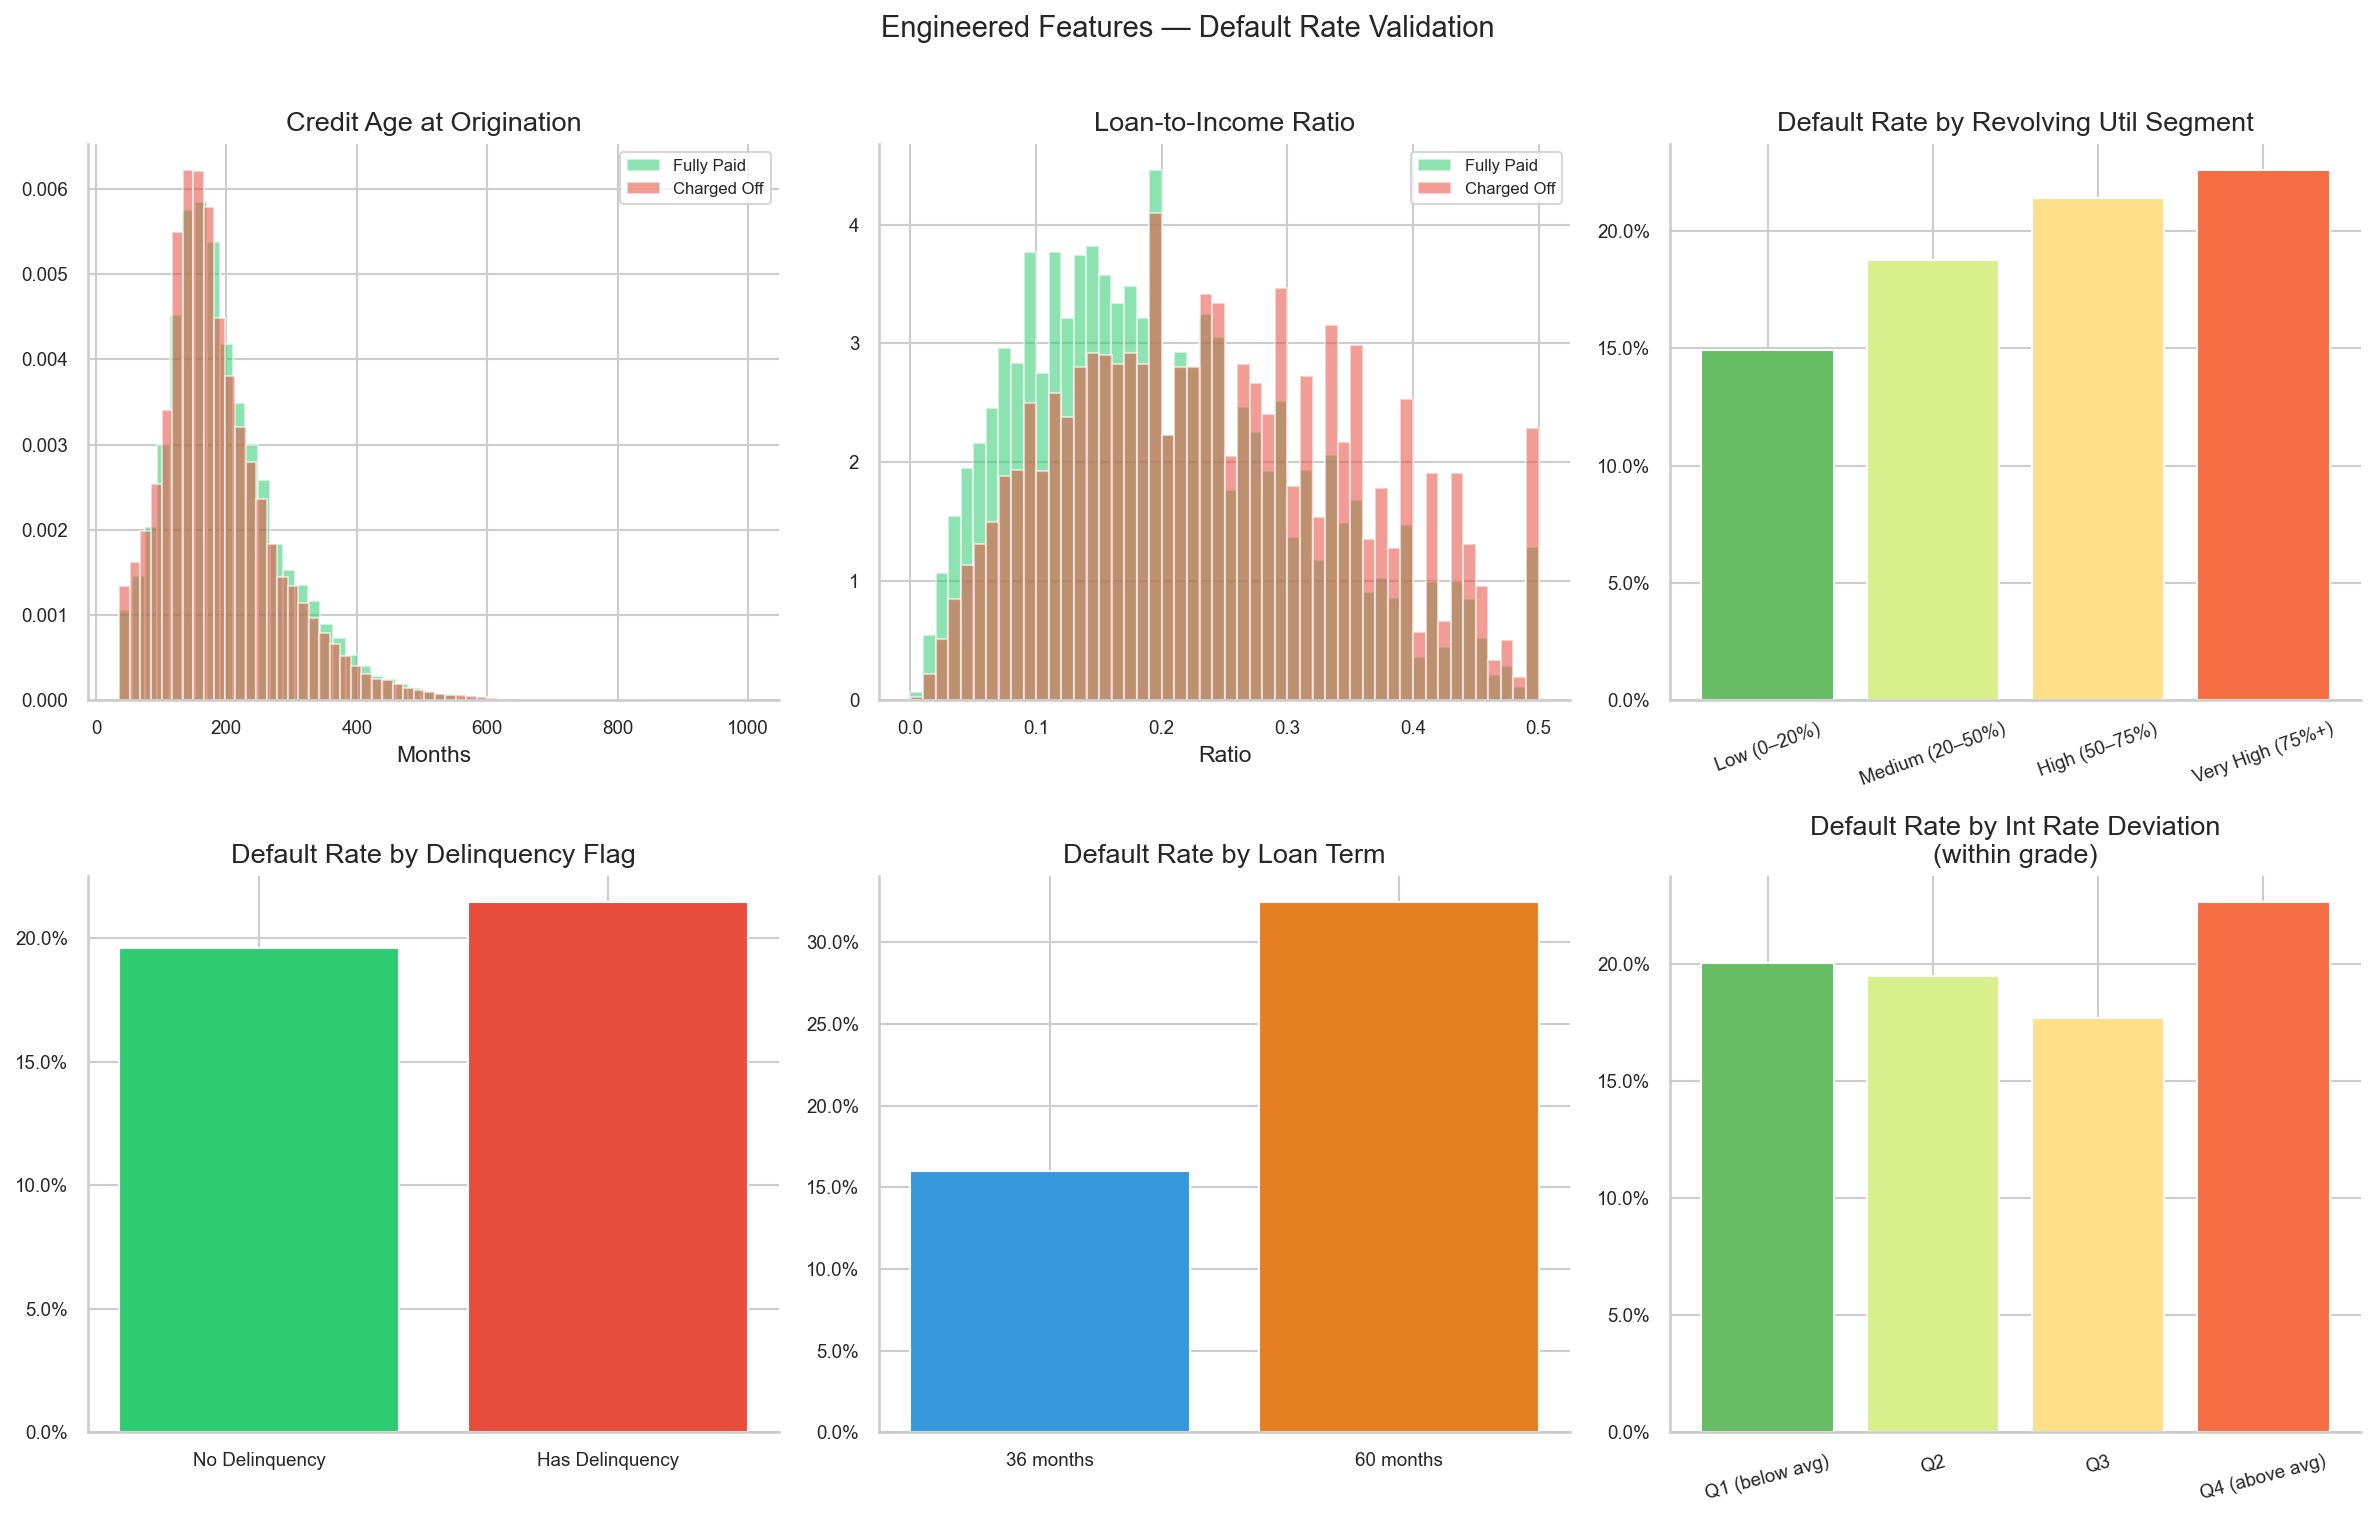

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. Credit age by default
for label, grp, color in [('Fully Paid', df[df['default']==0], '#2ecc71'),
                            ('Charged Off', df[df['default']==1], '#e74c3c')]:
    axes[0].hist(grp['credit_age_months'].dropna(), bins=50, alpha=0.55,
                 density=True, color=color, label=label, edgecolor='white')
axes[0].set_title("Credit Age at Origination")
axes[0].set_xlabel("Months")
axes[0].legend(fontsize=8)

# 2. Loan-to-income by default
for label, grp, color in [('Fully Paid', df[df['default']==0], '#2ecc71'),
                            ('Charged Off', df[df['default']==1], '#e74c3c')]:
    axes[1].hist(grp['loan_to_income'].dropna(), bins=50, alpha=0.55,
                 density=True, color=color, label=label, edgecolor='white')
axes[1].set_title("Loan-to-Income Ratio")
axes[1].set_xlabel("Ratio")
axes[1].legend(fontsize=8)

# 3. Revolving utilisation segment default rate
seg_rates = (df.groupby('revol_util_segment', observed=True)['default']
               .mean().reset_index())
colors = sns.color_palette("RdYlGn_r", len(seg_rates))
axes[2].bar(seg_rates['revol_util_segment'], seg_rates['default'],
            color=colors)
axes[2].set_title("Default Rate by Revolving Util Segment")
axes[2].set_xlabel("")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].tick_params(axis='x', rotation=20)

# 4. Delinquency flag default rate
delinq_rates = df.groupby('delinq_flag')['default'].mean().reset_index()
axes[3].bar(['No Delinquency', 'Has Delinquency'], delinq_rates['default'],
            color=['#2ecc71', '#e74c3c'])
axes[3].set_title("Default Rate by Delinquency Flag")
axes[3].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# 5. Term months default rate
term_rates = df.groupby('term_months')['default'].mean().reset_index()
axes[4].bar(term_rates['term_months'].astype(str) + ' months',
            term_rates['default'], color=['#3498db', '#e67e22'])
axes[4].set_title("Default Rate by Loan Term")
axes[4].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# 6. Interest rate deviation default rate
dev_rates = (df.groupby('rate_dev_quartile', observed=True)['default']
               .mean().reset_index())
colors2 = sns.color_palette("RdYlGn_r", len(dev_rates))
axes[5].bar(dev_rates['rate_dev_quartile'], dev_rates['default'], color=colors2)
axes[5].set_title("Default Rate by Int Rate Deviation\n(within grade)")
axes[5].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[5].tick_params(axis='x', rotation=15)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Engineered Features — Default Rate Validation", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}07_engineered_features.png", bbox_inches='tight')
plt.show()

---
## Part 6: Build the Model-Ready Dataset

Select the final feature set, handle missing values, encode categoricals, 
and save to disk so the modelling notebook can load it instantly without 
repeating all the above steps.

In [9]:
# ── Final feature selection ────────────────────────────────────────────────────
feature_cols = [
    # Original numeric
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'fico_mid', 'revol_util', 'open_acc', 'delinq_2yrs', 'pub_rec',
    'revol_bal', 'total_acc',
    # Engineered
    'credit_age_months', 'loan_to_income', 'instalment_to_income',
    'delinq_flag', 'pub_rec_flag', 'term_months', 'int_rate_grade_dev',
    # Categorical (will be encoded below)
    'grade', 'purpose', 'home_ownership',
    # Target
    'default'
]

model_df = df[feature_cols].copy()

# ── Missing value strategy ─────────────────────────────────────────────────────
# Numeric: fill with median (robust to outliers)
num_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'default']
for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Categorical: fill with mode
cat_cols = ['grade', 'purpose', 'home_ownership']
for col in cat_cols:
    model_df[col] = model_df[col].fillna(model_df[col].mode()[0])

# ── Encode categoricals ────────────────────────────────────────────────────────
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"Model dataset shape:  {model_df.shape}")
print(f"Missing values:       {model_df.isnull().sum().sum()}")
print(f"Default rate:         {model_df['default'].mean():.2%}")
print(f"\nFeature columns ({len(model_df.columns)-1}):")
for col in sorted(model_df.columns):
    if col != 'default':
        print(f"   {col}")

# ── Save ───────────────────────────────────────────────────────────────────────
OUT_PATH = "../data/processed/model_ready.parquet"
os.makedirs("../data/processed/", exist_ok=True)
model_df.to_parquet(OUT_PATH, index=False)
print(f"\n✓ Saved to {OUT_PATH}")

Model dataset shape:  (1345310, 44)
Missing values:       0
Default rate:         19.96%

Feature columns (43):
   annual_inc
   credit_age_months
   delinq_2yrs
   delinq_flag
   dti
   fico_mid
   grade_B
   grade_C
   grade_D
   grade_E
   grade_F
   grade_G
   home_ownership_MORTGAGE
   home_ownership_NONE
   home_ownership_OTHER
   home_ownership_OWN
   home_ownership_RENT
   installment
   instalment_to_income
   int_rate
   int_rate_grade_dev
   loan_amnt
   loan_to_income
   open_acc
   pub_rec
   pub_rec_flag
   purpose_credit_card
   purpose_debt_consolidation
   purpose_educational
   purpose_home_improvement
   purpose_house
   purpose_major_purchase
   purpose_medical
   purpose_moving
   purpose_other
   purpose_renewable_energy
   purpose_small_business
   purpose_vacation
   purpose_wedding
   revol_bal
   revol_util
   term_months
   total_acc

✓ Saved to ../data/processed/model_ready.parquet


---
## Feature Engineering Summary

| Feature | Source Columns | Business Rationale |
|---------|---------------|-------------------|
| `credit_age_months` | `earliest_cr_line`, `issue_d` | Longer credit history → more stable borrower |
| `loan_to_income` | `loan_amnt`, `annual_inc` | Affordability: loan size relative to earnings |
| `instalment_to_income` | `installment`, `annual_inc` | Monthly cash flow burden |
| `delinq_flag` | `delinq_2yrs` | Binary: any recent payment failure |
| `pub_rec_flag` | `pub_rec` | Binary: any public derogatory record |
| `term_months` | `term` | 60-month loans carry longer exposure |
| `int_rate_grade_dev` | `int_rate`, `grade` | Is this loan priced high within its tier? |
| `revol_util_segment` | `revol_util` | Credit limit usage behaviour |

**Next:** `03_modelling.ipynb` — Logistic Regression → Random Forest → XGBoost

In [10]:
saved = sorted(os.listdir(FIGURES_DIR))
print(f"✓ {len(saved)} total figures in reports/figures/")

processed_files = os.listdir("../data/processed/")
print(f"✓ Processed data: {processed_files}")

import os.path
size_mb = os.path.getsize("../data/processed/model_ready.parquet") / 1e6
print(f"✓ model_ready.parquet size: {size_mb:.1f} MB")

✓ 7 total figures in reports/figures/
✓ Processed data: ['model_ready.parquet']
✓ model_ready.parquet size: 41.5 MB
